## 1. ANALYZE DATA FROM THE FIRST USER STUDY

In [1]:
import bisect
import collections
import csv
import datetime as dt
import json
import pathlib
import random
import statistics as st

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

# Inline, NOT Agg. Agg is a file-writing backend that renders nothing in a
# notebook -- figures would silently come out blank.
%matplotlib inline

# Show tables IN FULL. The defaults truncate to 60 rows and a 80-char width,
# which cuts the per-driver tables off around the 9th participant.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", 400)      # every analysis table fits whole
                                            # (the largest is 60 driver x task
                                            # cells in 1.9); only the 1,446-row
                                            # per-label table truncates
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)   # never wrap columns

# Figures: bigger and sharper inline. FIG_SCALE multiplies every figsize below,
# so raising it here enlarges every figure in the notebook at once.
# For true zoom use the vector PDFs written to ../results/ -- those are
# resolution-independent, unlike anything rendered inline.
FIG_SCALE = 1.45
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
# Every figure written to ../results/ is a vector PDF (see save_pdf below).
plt.rcParams["savefig.format"] = "pdf"
try:                                        # 2x pixel density where supported
    get_ipython().run_line_magic("config", "InlineBackend.figure_format = 'retina'")
except Exception:
    pass

LABELS_PATH = pathlib.Path("../data/study1_data/user_loa_labels.csv")
RAW_PATH_ALL = pathlib.Path("../data/study1_data/raw_data.jsonl")
CAL_DIR_ALL = pathlib.Path("../data/study1_data/calibration_data")


### 1.1. Label evolution over the session

In [2]:
# colors
SERIES = [
    ("#2a78d6", "o", (0, ())),                 # blue    -- solid
    ("#eb6834", "s", (0, (6, 2))),             # orange  -- dashed
    ("#1baf7a", "^", (0, (1, 1.6))),           # aqua    -- dotted
    ("#eda100", "D", (0, (7, 2, 1.5, 2))),     # yellow  -- dash-dot
    ("#e87ba4", "v", (0, (3, 1.6))),           # magenta -- short dash
]
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK_2 = "#52514e"
INK_MUTED = "#8f8e88"
GRID = "#e6e5e1"

# LoA -> action, from decision_engine._LOA_POLICY. .
LOA_ACTIONS = {0: "none", 1: "suggest", 2: "ask approval", 3: "auto w/ veto", 4: "auto"}

# Canonical fcd_config keys are what the model uses and what the analysis groups
# by; these are only for axis labels and table indices.
TASK_LABEL = {
    "changesong": "Change song",
    "providetrafficnews": "Provide traffic news",
    "provideweatherupdate": "Provide weather update",
    "sendatextmessage": "Respond to a text message",
    "startaphonecall": "Respond to a phone call",
}
def task_label(k): return TASK_LABEL.get(k, k)

# LoA 0..4 is ORDINAL, not categorical: 0 and 1 are neighbours, 0 and 4 are
# opposites. A stacked bar over the levels therefore needs a SEQUENTIAL ramp
# (one hue, light -> dark), not the categorical hues above -- categorical colour
# would imply the levels are unordered alternatives.
# Checked: relative luminance strictly decreasing, every step >= 1.5:1 against
# SURFACE so even the palest segment is visible, adjacent steps 1.4-2.2:1.
LOA_RAMP = ['#b5d0de', '#89b2c7', '#5b8ea9', '#31708d', '#123c4f']


def _rel_lum(h):
    h = h.lstrip('#')
    ch = [int(h[i:i + 2], 16) / 255 for i in (0, 2, 4)]
    ch = [v / 12.92 if v <= 0.04045 else ((v + 0.055) / 1.055) ** 2.4 for v in ch]
    return 0.2126 * ch[0] + 0.7152 * ch[1] + 0.0722 * ch[2]


_L = [_rel_lum(x) for x in LOA_RAMP]
assert all(a > b for a, b in zip(_L, _L[1:])), "LOA_RAMP must be monotonic light->dark"

OUT_DIR = pathlib.Path("../results")
OUT_DIR.mkdir(parents=True, exist_ok=True)


def save_pdf(fig, name):
    """Write a figure to ../results/<name>.pdf as vector (resolution-independent)."""
    path = OUT_DIR / f"{name}.pdf"
    fig.savefig(path, format="pdf", facecolor=SURFACE, bbox_inches="tight")
    print(f"figure -> {path}")
    return path


In [3]:
def parse_iso(ts: str):
    try:
        return dt.datetime.fromisoformat(str(ts).strip())
    except Exception:
        return None


def load(path: pathlib.Path):
    """rows -> [(pid, session, window_idx, function, marks[])], sorted."""
    out = []
    with path.open("r", encoding="utf-8-sig", newline="") as f:
        for r in csv.DictReader(f):
            sid = (r.get("session_id") or "").strip()
            fn = (r.get("functionname") or "").strip()
            raw = (r.get("user_selected_loa") or "").strip()
            if not sid or not fn or not raw:
                continue
            try:
                w = int(float(r.get("window_idx") or ""))
            except ValueError:
                continue
            marks = []
            for part in raw.replace(",", ";").split(";"):
                part = part.strip()
                if not part:
                    continue
                try:
                    v = int(float(part))
                except ValueError:
                    print(f"[warn] un-parseable LoA {part!r} in {raw!r} -- ignored")
                    continue
                if not 0 <= v <= 4:
                    print(f"[warn] LoA {v} outside 0..4 in {raw!r} -- clamped")
                marks.append(max(0, min(4, v)))
            if not marks:
                continue
            out.append({
                "pid": (r.get("participantid") or "unknown").strip() or "unknown",
                "session": sid,
                "window": w,
                "function": fn,
                "marks": sorted(set(marks)),
                "start": parse_iso(r.get("window_start_timestamp") or ""),
            })
    return out


def panel(ax, rows, functions, colours, max_window):
    """One session: window_idx on x, marked LoA on y, one line per function."""
    for fn in functions:
        pts = sorted((r["window"], r["marks"]) for r in rows if r["function"] == fn)
        if not pts:
            continue
        colour, marker, dashes = colours[fn]
        xs = [w for w, _ in pts]
        ys = [sum(m) / len(m) for _, m in pts]
        # multi-mark range bars first, so the line and marker sit on top
        for w, m in pts:
            if len(m) > 1:
                ax.plot([w, w], [min(m), max(m)], color=colour, lw=4,
                        alpha=0.28, solid_capstyle="round", zorder=2)
        ax.plot(xs, ys, color=colour, lw=2, linestyle=dashes, marker=marker,
                markersize=7, markerfacecolor=colour, markeredgecolor=SURFACE,
                markeredgewidth=1.4, zorder=3, clip_on=False)

    ax.set_ylim(-0.35, 4.35)
    ax.set_yticks(range(5))
    ax.set_yticklabels([f"{k} · {LOA_ACTIONS[k]}" for k in range(5)],
                       fontsize=9, color=INK_2)
    ax.set_xlim(0.4, max_window + 0.6)
    step = 1 if max_window <= 20 else (2 if max_window <= 40 else 5)
    ax.set_xticks([w for w in range(1, max_window + 1) if w % step == 0 or w == 1])
    ax.tick_params(axis="x", labelsize=9, colors=INK_2, length=0)
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="y", color=GRID, lw=1, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.set_facecolor(SURFACE)

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages

path = LABELS_PATH
if not path.exists():
    raise FileNotFoundError(f"labels not found: {path}")
rows = load(path)
if not rows:
    raise ValueError("no usable label rows")

# Colour is assigned from the tasks present in the WHOLE file, before any
# per-participant filtering, so a task keeps the same colour on every page.
# Assigning per participant would recolour each page and make them
# incomparable. Fixed order, never cycled.
functions = sorted({r["function"] for r in rows})
if len(functions) > len(SERIES):
    raise ValueError(
        f"{len(functions)} distinct tasks but only {len(SERIES)} validated palette "
        f"slots. Extend SERIES with the next slot(s) of the categorical theme and "
        f"RE-RUN the palette validator before trusting the figure.\n  {functions}")
colours = {fn: SERIES[i] for i, fn in enumerate(functions)}

ALL_PIDS = sorted({r["pid"] for r in rows})
print(f"{len(ALL_PIDS)} participants: {ALL_PIDS}")


def label_evolution_figure(pid, prs):
    """One page: every session of one driver, sharing a y axis and an x range."""
    starts = {}
    for r in prs:
        sname = r["session"]
        if r["start"] is not None and (sname not in starts or r["start"] < starts[sname]):
            starts[sname] = r["start"]
    sess = sorted({r["session"] for r in prs},
                  key=lambda sname: (starts.get(sname) or dt.datetime.max, sname))
    ncols = min(len(sess), 2)
    nrows = (len(sess) + ncols - 1) // ncols
    max_window = max(r["window"] for r in prs)
    # ~0.19 in per window keeps a panel near 3:2. Wider flattens the vertical
    # axis until a 4 -> 0 step reads as a gentle slope, which is what this
    # figure exists to show.
    panel_w = max(4.5, min(0.19 * max_window, 7.5))
    fig, axes = plt.subplots(nrows, ncols, squeeze=False, sharey=True,
                             figsize=(FIG_SCALE * (1.6 + panel_w * ncols),
                                      FIG_SCALE * (4.1 * nrows + 1.7)))
    fig.patch.set_facecolor(SURFACE)
    for k, sid in enumerate(sess):
        ax = axes[k // ncols][k % ncols]
        srows = [r for r in prs if r["session"] == sid]
        panel(ax, srows, functions, colours, max_window)
        nw = len({r["window"] for r in srows})
        ax.set_title(f"session {sid[:8]}   ·   {len(srows)} labels over {nw} windows",
                     fontsize=10, color=INK, pad=10, loc="left")
        ax.set_xlabel("window number in session", fontsize=9, color=INK_2)
    for k in range(len(sess), nrows * ncols):
        axes[k // ncols][k % ncols].axis("off")

    # Every task keeps a legend entry, including any this driver was never asked
    # about, so the legend reads identically on every page and an absent line is
    # visibly absent rather than a missing task.
    handles = [Line2D([], [], color=colours[fn][0], marker=colours[fn][1],
                      linestyle=colours[fn][2], lw=2, markersize=7,
                      markeredgecolor=SURFACE, markeredgewidth=1.4, label=fn)
               for fn in functions]
    fig.legend(handles=handles, loc="lower center", ncol=min(len(functions), 3),
               frameon=False, fontsize=9, labelcolor=INK_2, bbox_to_anchor=(0.5, 0.0))
    fig.suptitle(f"Driver {pid} — LoA marked per task, over the session",
                 fontsize=12.5, color=INK, x=0.012, ha="left", y=0.985)
    fig.text(0.012, 0.925,
             "a point is one label; a vertical bar spans a multi-mark, plotted at its mean",
             fontsize=9, color=INK_MUTED, ha="left")
    fig.tight_layout(rect=(0, 0.09, 1, 0.90))
    return fig, sess


by_pid = collections.defaultdict(list)
for r in rows:
    by_pid[r["pid"]].append(r)

label_tables = {}
pdf_path = OUT_DIR / "label_evolution_all.pdf"
with PdfPages(pdf_path) as pdf:
    for pid in ALL_PIDS:
        prs = by_pid[pid]
        fig, sess = label_evolution_figure(pid, prs)
        pdf.savefig(fig, facecolor=SURFACE)     # one PAGE per participant
        plt.show()                              # and inline, in order
        order_of = {sid: i for i, sid in enumerate(sess, 1)}
        label_tables[pid] = pd.DataFrame([{
            "participantid": pid, "session_id": r["session"],
            "session_order": order_of[r["session"]], "window_idx": r["window"],
            "functionname": r["function"],
            "marked_loa": ";".join(map(str, r["marks"])), "n_marks": len(r["marks"]),
            "mean_loa": round(sum(r["marks"]) / len(r["marks"]), 3),
        } for r in prs]).sort_values(["session_order", "window_idx", "functionname"],
                                     ignore_index=True)
        never = [fn for fn in functions if fn not in {r["function"] for r in prs}]
        print(f"[p{pid}] {len(sess)} session(s), {len(prs)} labels"
              + (f"   never asked about: {never}" if never else ""))

print(f"\nmulti-page PDF ({len(ALL_PIDS)} pages) -> {pdf_path}")

# Table view: the numbers behind every page. Three of the five line colours sit
# below 3:1 contrast on a light surface, and the palette rule for that case
# requires a table view as relief.
display(pd.concat(label_tables.values(), ignore_index=True))


### 1.3. Segment dataset — join raw frames to label windows

Everything from here on is **cross-driver** and ignores `PARTICIPANT_ID`: the questions are comparative.

One *segment* = one label = one (window, prompt) pair. The join is the same one `scripts/build_loa_dataset.py` performs — `session_id` plus the frame timestamp falling inside `[window_start, window_end]` — reproduced here so the notebook is self-contained.

In [5]:
# Driver-state channels aggregated per segment. RAW log keys -- note 'eye_ar',
# which is what the collector writes for the model feature called 'ear'.
STATE_COLS = ['perclos', 'gaze_score', 'hr_delta', 'rr_delta', 'blink_rate', 'yawn_rate',
              'eye_ar', 'mar', 'speed_ratio_max', 'brake', 'steer', 'throttle',
              'is_junction', 'lead_distance_m']
# Kept per frame for the rPPG section (1.7) and the frame-rate figures.
KEEP_EXTRA = ['heart_rate', 'heart_rate_raw', 'respiratory_rate', 'hr_rejected',
              'perclos_raw', 'rppg_harmonic_rejects', 'face_present']


# Canonical task key. "Respond to a phone call" and "Start a phone call" already
# alias to the SAME key in fcd_config, so the model has always treated them as one
# task -- drivers 001-007 simply saw different wording from 008-012. Splitting them
# here would split a task the pipeline never split.
# fcd_config is loaded standalone: importing the ProVoice package pulls in main.py
# -> uvicorn, which is irrelevant here and not importable in every environment.
import importlib.util as _ilu
_spec = _ilu.spec_from_file_location("fcd_config", "../src/ProVoice/fcd_config.py")
_fcd = _ilu.module_from_spec(_spec); _spec.loader.exec_module(_fcd)
resolve_function_key = _fcd.resolve_function_key


def _secs_of_day(ts):
    """'HH:MM:SS.fff' (frames) or full ISO (label windows) -> seconds since midnight."""
    if not ts:
        return None
    s = str(ts).strip()
    try:
        d = dt.datetime.fromisoformat(s)
        return d.hour * 3600 + d.minute * 60 + d.second + d.microsecond / 1e6
    except Exception:
        pass
    try:
        h, m, sec = s.split(":")
        return int(h) * 3600 + int(m) * 60 + float(sec)
    except Exception:
        return None


def _num(v):
    """Frame value -> float, with bools as 0/1 and anything unusable as NaN."""
    if isinstance(v, bool):
        return 1.0 if v else 0.0
    if v is None:
        return np.nan
    try:
        f = float(v)
        return f if f == f else np.nan
    except Exception:
        return np.nan


# ---- 1. raw frames, ALL participants, keeping only the columns we need ------
frames_by_session = collections.defaultdict(list)
n_lines = n_bad = 0
for line in RAW_PATH_ALL.open("r", encoding="utf-8"):
    line = line.strip()
    if not line:
        continue
    n_lines += 1
    try:
        fr = json.loads(line)
    except Exception:
        n_bad += 1          # a truncated tail line is the usual cause
        continue
    t = _secs_of_day(fr.get("timestamp"))
    if t is None:
        continue
    slim = {k: fr.get(k) for k in STATE_COLS + KEEP_EXTRA}
    slim["t"] = t
    frames_by_session[fr["session_id"]].append(slim)
for sid in frames_by_session:
    frames_by_session[sid].sort(key=lambda r: r["t"])
print(f"[raw] {n_lines} lines, {n_bad} unparseable, "
      f"{sum(len(v) for v in frames_by_session.values())} frames, "
      f"{len(frames_by_session)} sessions")

# ---- 2. one segment per label row ------------------------------------------
segments = []
for r in csv.DictReader(LABELS_PATH.open(encoding="utf-8-sig", newline="")):
    sid = (r.get("session_id") or "").strip()
    marks = sorted({max(0, min(4, int(float(x))))
                    for x in (r.get("user_selected_loa") or "").replace(",", ";").split(";")
                    if x.strip()})
    a, b = _secs_of_day(r.get("window_start_timestamp")), _secs_of_day(r.get("window_end_timestamp"))
    if not sid or not marks or a is None or b is None:
        continue
    fr = frames_by_session.get(sid, [])
    ts = [f["t"] for f in fr]
    lo, hi = bisect.bisect_left(ts, a), bisect.bisect_right(ts, b)
    win = fr[lo:hi]
    seg = {
        "pid": (r.get("participantid") or "unknown").strip() or "unknown",
        "session": sid,
        "window": int(float(r["window_idx"])),
        "prompt": int(float(r.get("prompt_in_window") or 0)),
        "function_raw": (r.get("functionname") or "").strip(),
        "function": resolve_function_key((r.get("functionname") or "").strip()),
        "marks": marks,
        "y": float(np.mean(marks)),          # scalar summary of the marked SET
        "n_marks": len(marks),
        "n_frames": len(win),
        "sel_s": _secs_of_day(r.get("selection_timestamp")),
        "end_s": b,
    }
    for c in STATE_COLS:                     # mean and sd over the 20 s window
        v = np.array([_num(f.get(c)) for f in win], dtype=float)
        v = v[~np.isnan(v)]
        seg[f"{c}_mean"] = float(v.mean()) if v.size else np.nan
        seg[f"{c}_std"] = float(v.std()) if v.size else np.nan
    # Window-mean heart rate, kept for the data-quality filter in 1.11 (it is not a
    # model feature -- hr_delta is).
    _hr = np.array([_num(f.get("heart_rate")) for f in win], dtype=float)
    _hr = _hr[~np.isnan(_hr)]
    seg["hr_mean"] = float(_hr.mean()) if _hr.size else np.nan
    segments.append(seg)

# Session order is CHRONOLOGICAL (first window), not the uuid's sort order.
_first = {}
for s in segments:
    k = (s["pid"], s["session"])
    _first[k] = min(_first.get(k, 1e18), s["end_s"])
_order = {}
for pid in {p for p, _ in _first}:
    for i, (p, sid) in enumerate(sorted([k for k in _first if k[0] == pid],
                                        key=lambda k: _first[k]), 1):
        _order[(p, sid)] = i
_maxw = collections.defaultdict(int)
for s in segments:
    _maxw[(s["pid"], s["session"])] = max(_maxw[(s["pid"], s["session"])], s["window"])
for s in segments:
    s["session_order"] = _order[(s["pid"], s["session"])]
    n = _maxw[(s["pid"], s["session"])]
    s["t_norm"] = (s["window"] - 1) / (n - 1) if n > 1 else 0.0   # 0..1 through the session

seg_df = pd.DataFrame(segments)
STATE_FEATS = [c for c in seg_df.columns
               if c.endswith(("_mean", "_std")) and c != "hr_mean"]
DRIVERS = sorted(seg_df.pid.unique())
FUNCTIONS = sorted(seg_df.function.unique())
print(f"[segments] {len(seg_df)} | drivers {DRIVERS} | {len(FUNCTIONS)} tasks | "
      f"{len(STATE_FEATS)} state features")
_merged = seg_df.groupby("function").function_raw.nunique()
for k, v in _merged[_merged > 1].items():
    print(f"[tasks] {k!r} merges {sorted(seg_df.loc[seg_df.function == k, 'function_raw'].unique())}")
print(f"[coverage] frames per segment: min={seg_df.n_frames.min()} "
      f"med={int(seg_df.n_frames.median())} max={seg_df.n_frames.max()}"
      f" | segments with ZERO frames: {(seg_df.n_frames == 0).sum()}")
display(seg_df[["pid", "session_order", "window", "prompt", "function",
                "n_marks", "y", "n_frames"]].head())


[raw] 380990 lines, 0 unparseable, 380990 frames, 24 sessions
[segments] 1446 | drivers ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012'] | 5 tasks | 28 state features
[coverage] frames per segment: min=80 med=381 max=396 | segments with ZERO frames: 0


,pid,session_order,window,prompt,function,n_marks,y,n_frames
0,001,1,1,1,providetrafficnews,1,4.0,87
1,001,1,1,2,sendatextmessage,1,2.0,87
2,001,1,2,1,sendatextmessage,1,2.0,88
3,001,1,2,2,changesong,1,4.0,88
4,001,1,3,1,startaphonecall,1,3.0,84


### 1.4. Label distribution — per driver and per task

In [9]:
def level_row(sub_marks, name):
    """One row of a frequency table: per-level mark counts + summary stats."""
    marks = [m for s in sub_marks for m in s]
    c = collections.Counter(marks)
    row = {"group": name, "labels": len(sub_marks), "marks": len(marks)}
    for k in range(5):
        row[f"L{k}"] = c.get(k, 0)
    for k in range(5):
        row[f"L{k}_%"] = round(100 * c.get(k, 0) / len(marks), 1) if marks else 0.0
    row["mean"] = round(float(np.mean(marks)), 3)
    row["sd"] = round(float(np.std(marks)), 3)
    multi = [s for s in sub_marks if len(s) > 1]
    row["multi_%"] = round(100 * len(multi) / len(sub_marks), 1)
    row["non_contig"] = sum(1 for s in multi if (max(s) - min(s) + 1) != len(s))
    return row


COUNT_COLS = ["group", "labels", "marks"] + [f"L{k}" for k in range(5)] \
             + ["mean", "sd", "multi_%", "non_contig"]
PCT_COLS = ["group", "marks"] + [f"L{k}_%" for k in range(5)]

# ---- by DRIVER --------------------------------------------------------------
rows = [level_row(seg_df.loc[seg_df.pid == p, "marks"].tolist(), p) for p in DRIVERS]
rows.append(level_row(seg_df["marks"].tolist(), "ALL"))
freq_driver = pd.DataFrame(rows)
print("Level frequency BY DRIVER (a multi-mark counts toward every level it names)")
display(freq_driver[COUNT_COLS])
print("Same, as a percentage of that driver's marks")
display(freq_driver[PCT_COLS])

# ---- by TASK ----------------------------------------------------------------
rows = [level_row(seg_df.loc[seg_df.function == f, "marks"].tolist(), task_label(f))
        for f in FUNCTIONS]
rows.append(level_row(seg_df["marks"].tolist(), "ALL"))
freq_function = pd.DataFrame(rows)
print("Level frequency BY TASK")
display(freq_function[COUNT_COLS])
print("Same, as a percentage of that task's marks")
display(freq_function[PCT_COLS])

# ---- per driver x task, and how much of it is the DRIVER --------------------
pf = (seg_df.groupby(["pid", "function"])["y"]
      .agg(n="size", mean="mean", sd=lambda v: float(np.std(v))).reset_index())
mean_w = pf.pivot(index="function", columns="pid", values="mean")
sd_w = pf.pivot(index="function", columns="pid", values="sd")

summary = pd.DataFrame({
    "pop mean": mean_w.mean(axis=1).round(2),
    "between-driver sd": mean_w.std(axis=1).round(2),
    "min": mean_w.min(axis=1).round(2),
    "max": mean_w.max(axis=1).round(2),
    "range": (mean_w.max(axis=1) - mean_w.min(axis=1)).round(2),
    "within-driver sd": sd_w.mean(axis=1).round(2),
})


Level frequency BY DRIVER (a multi-mark counts toward every level it names)


,group,labels,marks,L0,L1,L2,L3,L4,mean,sd,multi_%,non_contig
0,001,124,131,27,11,27,18,48,2.374,1.540,5.6,0
1,002,94,121,41,14,12,47,7,1.711,1.417,19.1,0
2,003,122,122,40,23,12,15,32,1.803,1.623,0.0,0
3,004,114,137,54,61,22,0,0,0.766,0.707,20.2,0
4,005,120,134,22,6,21,41,44,2.590,1.405,11.7,1
5,006,116,128,56,21,41,10,0,1.039,1.034,10.3,0
6,007,136,136,34,49,2,0,51,1.890,1.688,0.0,0
7,008,126,130,59,50,20,1,0,0.715,0.747,3.2,0
8,009,134,154,63,34,1,0,56,1.688,1.793,14.9,0
9,010,128,128,82,1,24,0,21,1.039,1.518,0.0,0


Same, as a percentage of that driver's marks


,group,marks,L0_%,L1_%,L2_%,L3_%,L4_%
0,001,131,20.6,8.4,20.6,13.7,36.6
1,002,121,33.9,11.6,9.9,38.8,5.8
2,003,122,32.8,18.9,9.8,12.3,26.2
3,004,137,39.4,44.5,16.1,0.0,0.0
4,005,134,16.4,4.5,15.7,30.6,32.8
5,006,128,43.8,16.4,32.0,7.8,0.0
6,007,136,25.0,36.0,1.5,0.0,37.5
7,008,130,45.4,38.5,15.4,0.8,0.0
8,009,154,40.9,22.1,0.6,0.0,36.4
9,010,128,64.1,0.8,18.8,0.0,16.4


Level frequency BY TASK


,group,labels,marks,L0,L1,L2,L3,L4,mean,sd,multi_%,non_contig
0,Change song,276,285,147,35,16,22,65,1.379,1.670,3.3,0
1,Provide traffic news,307,313,92,61,14,25,121,2.070,1.730,2.0,0
2,Provide weather update,275,280,103,32,7,19,119,2.068,1.830,1.8,0
3,Respond to a text message,296,337,112,112,67,39,7,1.160,1.075,12.2,0
4,Respond to a phone call,292,338,58,79,121,73,7,1.680,1.057,14.4,1
5,ALL,1446,1553,512,319,225,178,319,1.661,1.531,6.8,1


Same, as a percentage of that task's marks


,group,marks,L0_%,L1_%,L2_%,L3_%,L4_%
0,Change song,285,51.6,12.3,5.6,7.7,22.8
1,Provide traffic news,313,29.4,19.5,4.5,8.0,38.7
2,Provide weather update,280,36.8,11.4,2.5,6.8,42.5
3,Respond to a text message,337,33.2,33.2,19.9,11.6,2.1
4,Respond to a phone call,338,17.2,23.4,35.8,21.6,2.1
5,ALL,1553,33.0,20.5,14.5,11.5,20.5


### 1.4.1. Labels collected per driver

How many label rows each driver produced, where one label = one `(window, prompt)` pair 
(every 20 s window carried two prompts, `--random-function`). Counted straight from 
`user_loa_labels.csv` so join losses in `seg_df` do not affect the totals. 
`windows` is the same count divided by prompt, i.e. distinct 20 s windows labelled.

In [6]:
# Labels collected per driver -- read directly from the labels CSV.
_lab_path = next(p for p in [pathlib.Path("../data/user_loa_labels.csv"),
                             pathlib.Path("../data/study1_data/user_loa_labels.csv")]
                 if p.exists())
_labels_raw = pd.read_csv(_lab_path, dtype={"participantid": str}, encoding="utf-8-sig")

labels_per_driver = (_labels_raw.groupby("participantid").size()
                     .rename("labels").sort_index())
windows_per_driver = (_labels_raw.drop_duplicates(["session_id", "window_idx"])
                      .groupby("participantid").size().rename("windows").sort_index())

per_driver_label_counts = pd.concat([labels_per_driver, windows_per_driver], axis=1)
print(f"Labels collected per driver  (source: {_lab_path})")
display(per_driver_label_counts)

labels_count_summary = pd.DataFrame({
    "mean": [labels_per_driver.mean(), windows_per_driver.mean()],
    "sd":   [labels_per_driver.std(ddof=1), windows_per_driver.std(ddof=1)],
    "min":  [labels_per_driver.min(), windows_per_driver.min()],
    "max":  [labels_per_driver.max(), windows_per_driver.max()],
}, index=["labels (window x prompt)", "windows"]).round(2)
print(f"Across the {labels_per_driver.size} drivers "
      f"(total {int(labels_per_driver.sum())} labels over "
      f"{int(windows_per_driver.sum())} windows)")
display(labels_count_summary)

Labels collected per driver  (source: ..\data\study1_data\user_loa_labels.csv)


,labels,windows
participantid,,
001,124,62
002,94,47
003,122,61
004,114,57
005,120,60
006,116,58
007,136,68
008,126,63
009,134,67


Across the 12 drivers (total 1446 labels over 723 windows)


,mean,sd,min,max
labels (window x prompt),120.50,10.99,94,136
windows,60.25,5.50,47,68


#### Level mix as a figure

The two percentage tables above, drawn. Each bar is one driver (or one task), split into five sections whose heights are the share of that group's marks at each level — so every bar sums to 100 %.

The levels are **ordinal**, so the fill is a single-hue sequential ramp running light (LoA 0, never act) to dark (LoA 4, always act). Categorical colours would wrongly imply the five levels are unordered alternatives.

figure -> ..\results\label_distribution.pdf


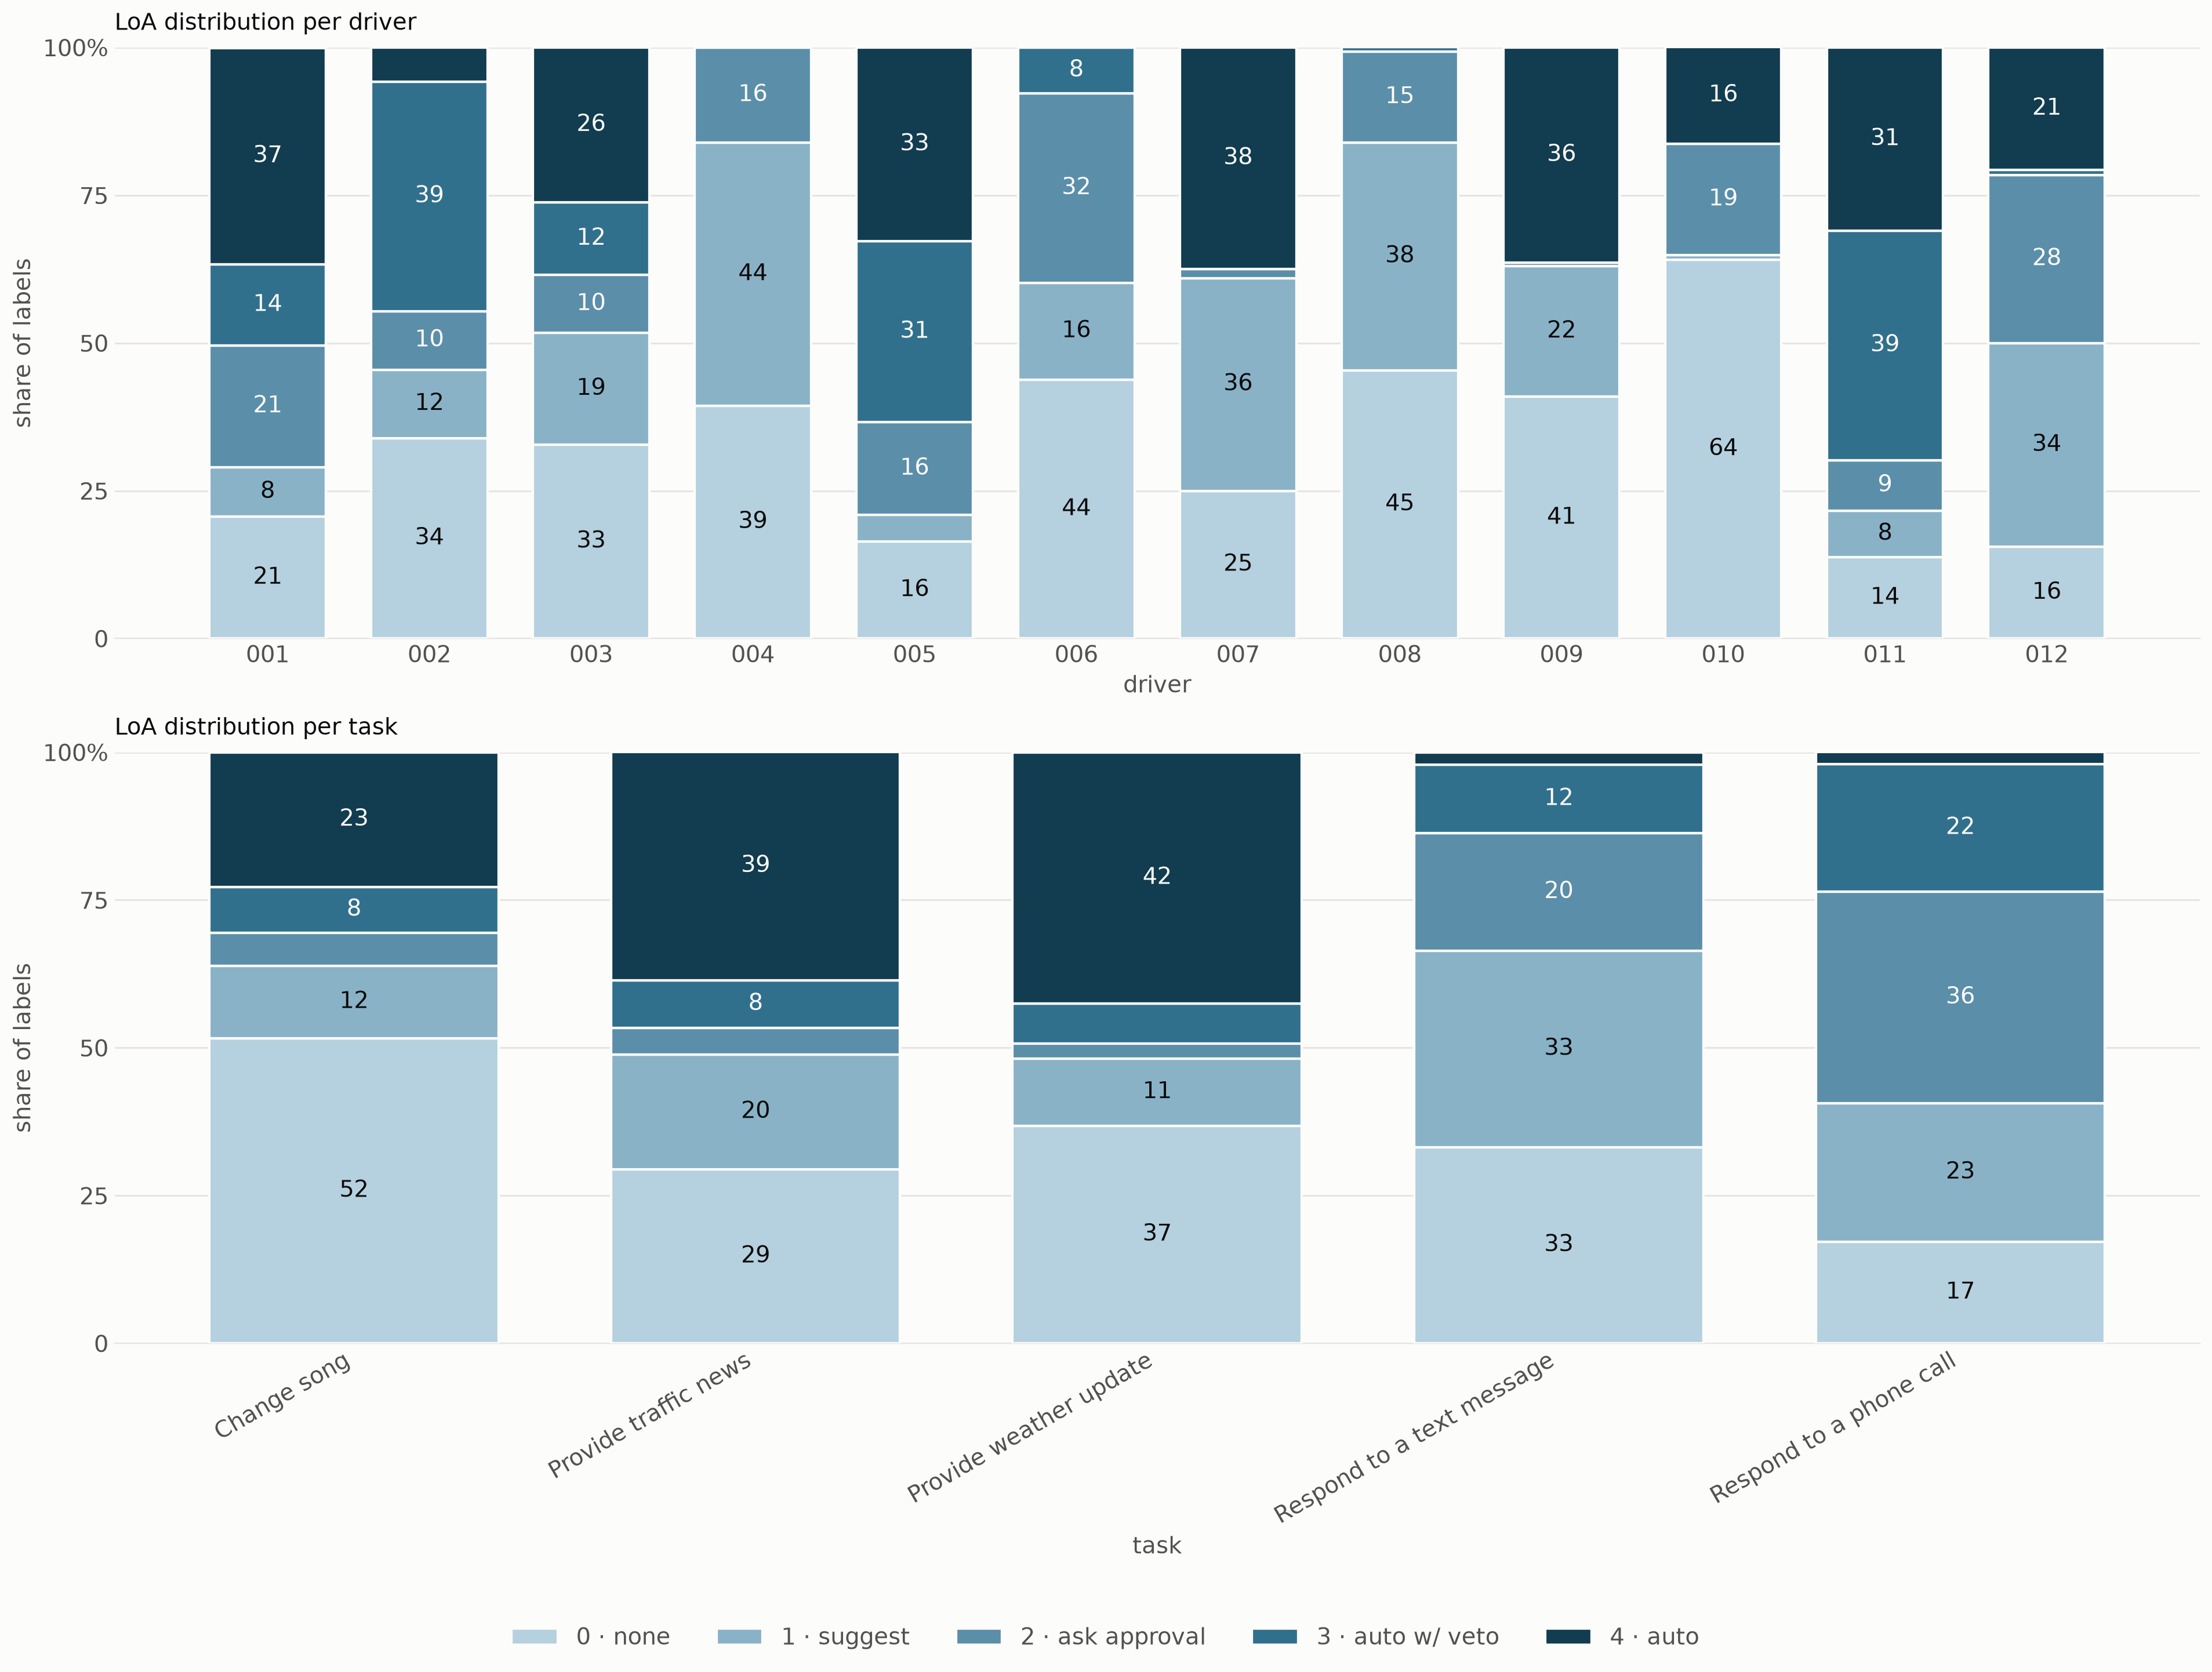

Drivers occupying different parts of the scale is the personalization signal.
Tasks looking alike is the same finding from the other side: task identity
does not determine the level, which is why the population model has little
to learn (see 1.8 and 1.9).


In [10]:
def stacked_levels(ax, groups, pct, title, xlabel):
    """100% stacked bars: one bar per group, one section per LoA."""
    xs = np.arange(len(groups))
    bottom = np.zeros(len(groups))
    for k in range(5):
        h = pct[:, k]
        ax.bar(xs, h, bottom=bottom, width=0.72, color=LOA_RAMP[k],
               edgecolor=SURFACE, linewidth=1.4, zorder=3,
               label=f"{k} · {LOA_ACTIONS[k]}")
        for i, (b, hh) in enumerate(zip(bottom, h)):
            if hh >= 7:                      # only label a section with room for it
                ax.text(xs[i], b + hh / 2, f"{hh:.0f}", ha="center", va="center",
                        fontsize=13, zorder=4,
                        color=(INK if k < 2 else SURFACE))
        bottom += h
    ax.set_xticks(xs)
    ax.set_xticklabels(groups, fontsize=13, color=INK_2,
                       rotation=0 if max(len(g) for g in groups) <= 6 else 30,
                       ha="center" if max(len(g) for g in groups) <= 6 else "right")
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_yticklabels(["0", "25", "50", "75", "100%"], fontsize=13, color=INK_2)
    ax.set_ylabel("share of labels", fontsize=13, color=INK_2)
    ax.set_xlabel(xlabel, fontsize=13, color=INK_2)
    ax.set_title(title, fontsize=13, color=INK, loc="left", pad=10)
    ax.grid(axis="y", color=GRID, lw=1, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.set_facecolor(SURFACE)


PCT = [f"L{k}_%" for k in range(5)]
d_groups = [g for g in freq_driver.group if g != "ALL"]
d_pct = freq_driver[freq_driver.group != "ALL"][PCT].to_numpy(float)
f_groups = [g for g in freq_function.group if g != "ALL"]
f_pct = freq_function[freq_function.group != "ALL"][PCT].to_numpy(float)

fig, axes = plt.subplots(
    2, 1, figsize=(FIG_SCALE * max(7.5, 0.72 * max(len(d_groups), len(f_groups)) + 3.4),
                   FIG_SCALE * 9.4))
fig.patch.set_facecolor(SURFACE)
stacked_levels(axes[0], d_groups, d_pct,
               "LoA distribution per driver", "driver")
stacked_levels(axes[1], f_groups, f_pct,
               "LoA distribution per task", "task")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False,
           fontsize=13, labelcolor=INK_2, bbox_to_anchor=(0.5, 0.0))

fig.tight_layout(rect=(0, 0.055, 1, 0.965))
save_pdf(fig, "label_distribution")
plt.show()

print("Drivers occupying different parts of the scale is the personalization signal.")
print("Tasks looking alike is the same finding from the other side: task identity")
print("does not determine the level, which is why the population model has little")
print("to learn (see 1.8 and 1.9).")


#### General label distribution

The overall LoA mix — the `ALL` row of the tables above — as a pie. 
Wedges use the same sequential `LOA_RAMP` as the stacked bars, so a wedge and a 
bar section for the same level are the same colour. A multi-mark counts toward 
every level it names, so the wedges sum to the number of *marks*, not labels.

figure -> ..\results\label_distribution_pie.pdf


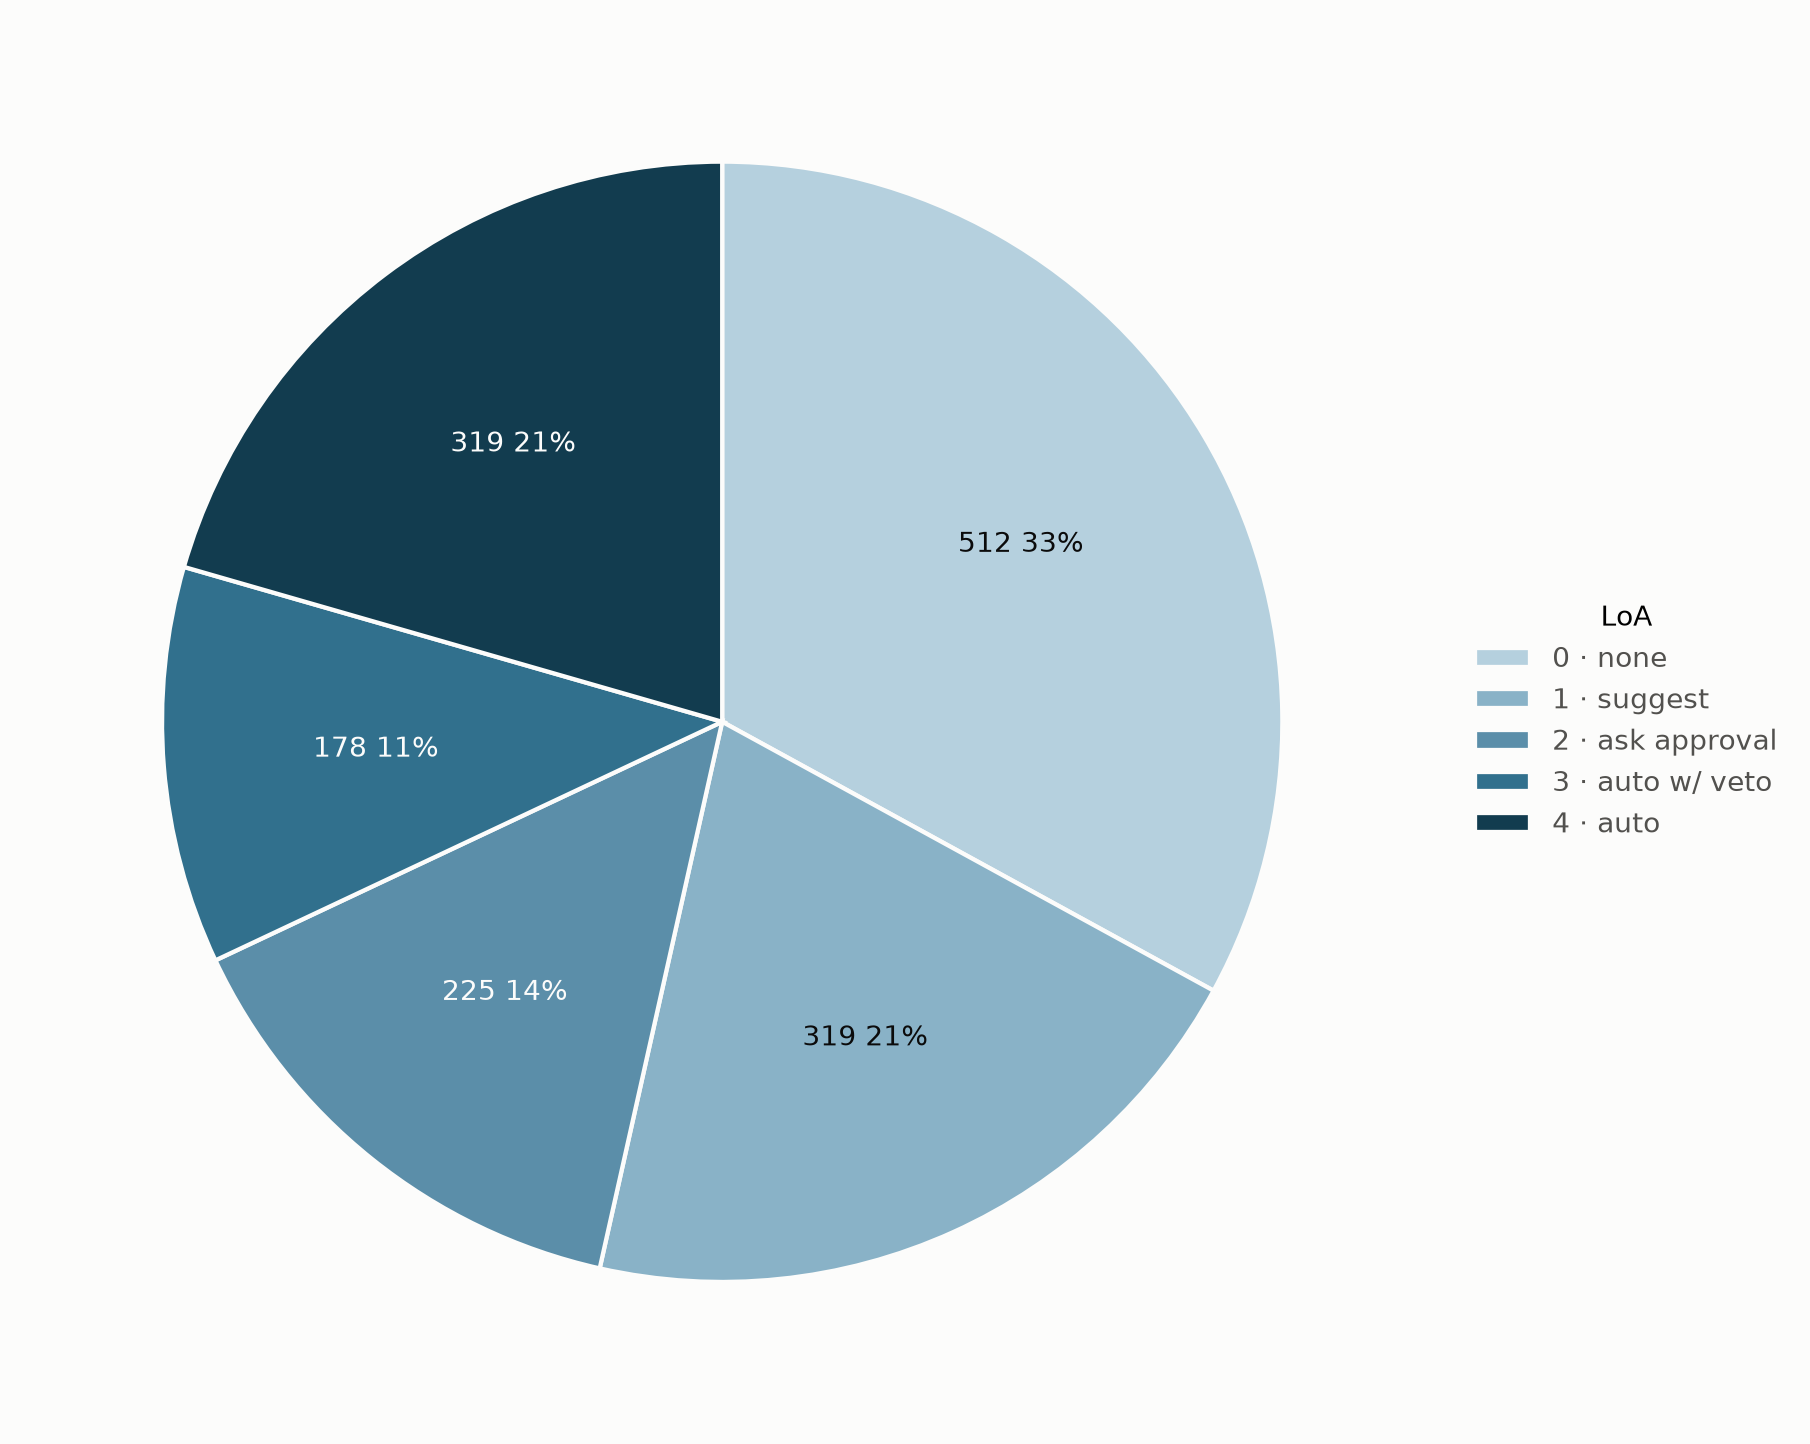

In [11]:
# General label distribution: the overall LoA mix across every mark in the
# study, drawn with the SAME LOA_RAMP as the stacked bars above.
_all = freq_driver.loc[freq_driver.group == "ALL"].iloc[0]
_counts = np.array([_all[f"L{k}"] for k in range(5)], float)
_share = 100 * _counts / _counts.sum()

fig, ax = plt.subplots(figsize=(FIG_SCALE * 5.4, FIG_SCALE * 4.6))
fig.patch.set_facecolor(SURFACE)
wedges, _ = ax.pie(_counts, colors=LOA_RAMP, startangle=90, counterclock=False,
                   wedgeprops=dict(edgecolor=SURFACE, linewidth=1.4))
for k, w in enumerate(wedges):
    if _share[k] < 3:                       # too thin to label in place
        continue
    ang = np.deg2rad(0.5 * (w.theta1 + w.theta2))
    ax.text(0.62 * np.cos(ang), 0.62 * np.sin(ang),
            f"{_counts[k]:.0f} {_share[k]:.0f}%", ha="center", va="center",
            fontsize=9, zorder=4, color=(INK if k < 2 else SURFACE))
ax.set_aspect("equal")
ax.legend(wedges, [f"{k} · {LOA_ACTIONS[k]}" for k in range(5)],
          loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False,
          fontsize=9, labelcolor=INK_2, title="LoA", title_fontsize=9)
fig.tight_layout()
save_pdf(fig, "label_distribution_pie")
plt.show()


### 1.5. Drift — do preferences move within a session?

A raw first-half/second-half difference confounds real drift with *which functions happened to be asked when*. The OLS regresses the marked level on function dummies **plus** normalised time-in-session, so the time slope is the drift with function composition held constant.

**On the empty cells in the thirds table.** A cell is `NaN` when that driver was never asked about that task during that third of that session. The drive UI draws two tasks at random per window from a pool of five (`RANDOM_FUNCTION_POOL`), so with ~10 windows per third that is ~20 draws spread over 5 tasks — about 4 per task, and occasionally none. The probability a given task is drawn zero times in a third is roughly $(4/5)^{20} \approx 0.012$, so a handful of empty cells out of 360 is expected. The cell below reports the actual count; **it is a sampling gap, not a logging failure**, and the shortest sessions are where it shows up.

In [12]:
def time_slope(sub):
    """OLS  y ~ function dummies + normalised time.  -> (slope, se, t).

    Function dummies with no intercept: they span it, so the time coefficient is
    the within-function drift rather than a mixture of drift and composition.
    """
    y = sub["y"].to_numpy(float)
    t = sub["t_norm"].to_numpy(float)
    fl = sorted(sub["function"].unique())
    D = np.zeros((len(sub), len(fl)))
    for i, f in enumerate(sub["function"]):
        D[i, fl.index(f)] = 1.0
    X = np.column_stack([D, t])
    if len(y) <= X.shape[1]:
        return np.nan, np.nan, np.nan
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    res = y - X @ beta
    s2 = res @ res / (len(y) - X.shape[1])
    se = float(np.sqrt(np.diag(s2 * np.linalg.pinv(X.T @ X))[-1]))
    return float(beta[-1]), se, (float(beta[-1]) / se if se > 0 else np.nan)


rows = []
for (pid, order), sub in seg_df.groupby(["pid", "session_order"]):
    nw = sub["window"].max()
    h1 = sub.loc[sub.window <= nw / 2, "y"]
    h2 = sub.loc[sub.window > nw / 2, "y"]
    slope, se, tstat = time_slope(sub)
    rows.append({
        "driver": f"p{pid}", "session": order, "n": len(sub), "windows": nw,
        "1st half": round(h1.mean(), 3), "2nd half": round(h2.mean(), 3),
        "half diff": round(h2.mean() - h1.mean(), 3),
        "fn-adj slope": round(slope, 3), "se": round(se, 3), "t": round(tstat, 2),
        "significant": "YES" if abs(tstat) > 2 else "no",
    })
print("Drift per session  (slope = change in marked LoA across the whole session)")
display(pd.DataFrame(rows))

# Per driver x function x third -- where in the scale the drift actually happens.
thirds = []
for (pid, order, fn), sub in seg_df.groupby(["pid", "session_order", "function"]):
    nw = _maxw[(pid, sub["session"].iloc[0])]
    cells = {}
    for k in range(3):
        sel = sub[(sub.window > nw * k / 3) & (sub.window <= nw * (k + 1) / 3)]
        cells[f"T{k+1}"] = round(sel["y"].mean(), 2) if len(sel) else np.nan
        cells[f"n{k+1}"] = len(sel)
    vals = [v for kk, v in cells.items() if kk.startswith("T") and v == v]
    thirds.append({"driver": f"p{pid}", "session": order, "function": fn, **cells,
                   "shape": ("stable" if not vals or max(vals) - min(vals) < 0.8
                             else "DROP" if vals[-1] < vals[0] - 0.8 else "RISE")})
print("By third of the session, per driver x function")
display(pd.DataFrame(thirds).sort_values(["driver", "session", "function"], ignore_index=True))


# Why are some cells empty? Quantify it rather than leaving a NaN unexplained.
_cells = pd.DataFrame(thirds)
_n_cols = [f"n{k}" for k in (1, 2, 3)]
_empty = int((_cells[_n_cols] == 0).to_numpy().sum())
_total = int(_cells[_n_cols].size)
_wins = seg_df.groupby(["pid", "session_order"]).window.nunique()
_per_third = 2 * _wins.median() / 3          # 2 prompts per window
_p0 = (1 - 1 / len(FUNCTIONS)) ** _per_third
print(f"\nEmpty (driver x session x task x third) cells: {_empty}/{_total} "
      f"({100*_empty/_total:.1f}%)")
print(f"  windows per session: min={_wins.min()} median={int(_wins.median())} "
      f"max={_wins.max()}  ->  ~{_per_third:.0f} prompts per third")
print(f"  tasks are drawn 2-at-random per window from {len(FUNCTIONS)}, so a given task")
print(f"  is missed in a third with p ~ {_p0:.3f}  ->  ~{_p0*_total:.0f} empty cells expected")
print("  => a sampling gap, not a logging failure.")
if _empty:
    _bad = _cells[(_cells[_n_cols] == 0).any(axis=1)][["driver", "session", "function"] + _n_cols]
    print("\n  the affected rows:")
    display(_bad)


Drift per session  (slope = change in marked LoA across the whole session)


,driver,session,n,windows,1st half,2nd half,half diff,fn-adj slope,se,t,significant
0,p001,1,60,30,3.250,1.883,-1.367,-2.693,0.482,-5.59,YES
1,p001,2,64,32,2.594,1.672,-0.922,-1.141,0.492,-2.32,YES
2,p002,1,40,20,1.600,2.125,0.525,0.187,0.422,0.44,no
3,p002,2,54,27,1.846,1.679,-0.168,-0.399,0.443,-0.90,no
4,p003,1,60,30,1.767,2.033,0.267,-0.097,0.257,-0.38,no
5,p003,2,62,31,1.467,1.938,0.471,0.419,0.244,1.72,no
6,p004,1,56,28,0.821,0.375,-0.446,-0.322,0.150,-2.14,YES
7,p004,2,58,29,0.625,0.683,0.058,0.163,0.199,0.82,no
8,p005,1,58,29,2.536,2.417,-0.119,0.314,0.343,0.91,no
9,p005,2,62,31,2.567,2.953,0.386,0.190,0.158,1.21,no


By third of the session, per driver x function


,driver,session,function,T1,n1,T2,n2,T3,n3,shape
0,p001,1,changesong,3.67,3,3.75,6,4.00,2,stable
1,p001,1,providetrafficnews,4.00,2,4.00,3,0.00,5,DROP
2,p001,1,provideweatherupdate,4.00,6,3.75,2,0.00,5,DROP
3,p001,1,sendatextmessage,2.00,4,2.00,3,0.90,5,DROP
4,p001,1,startaphonecall,2.80,5,3.33,6,2.83,3,stable
5,p001,2,changesong,4.00,6,3.80,5,3.67,6,stable
6,p001,2,providetrafficnews,3.33,3,0.67,3,0.60,5,DROP
7,p001,2,provideweatherupdate,2.50,4,0.00,4,0.58,6,DROP
8,p001,2,sendatextmessage,1.60,5,2.00,6,2.00,1,stable
9,p001,2,startaphonecall,2.00,2,2.00,4,2.25,4,stable



Empty (driver x session x task x third) cells: 1/360 (0.3%)
  windows per session: min=20 median=30 max=35  ->  ~20 prompts per third
  tasks are drawn 2-at-random per window from 5, so a given task
  is missed in a third with p ~ 0.012  ->  ~4 empty cells expected
  => a sampling gap, not a logging failure.

  the affected rows:


,driver,session,function,n1,n2,n3
11,p002,1,providetrafficnews,3,3,0


#### Trend per driver — six points per task

Each driver gets one line per task with **six points**: the mean marked level in each third of session 1, then each third of session 2. A gap in a line is a third where that task was never drawn (see the note above).

The dashed divider separates the two sessions, so a level that resets between sessions is distinguishable from one that keeps sliding.

figure -> ..\results\trend_by_third_overview.pdf


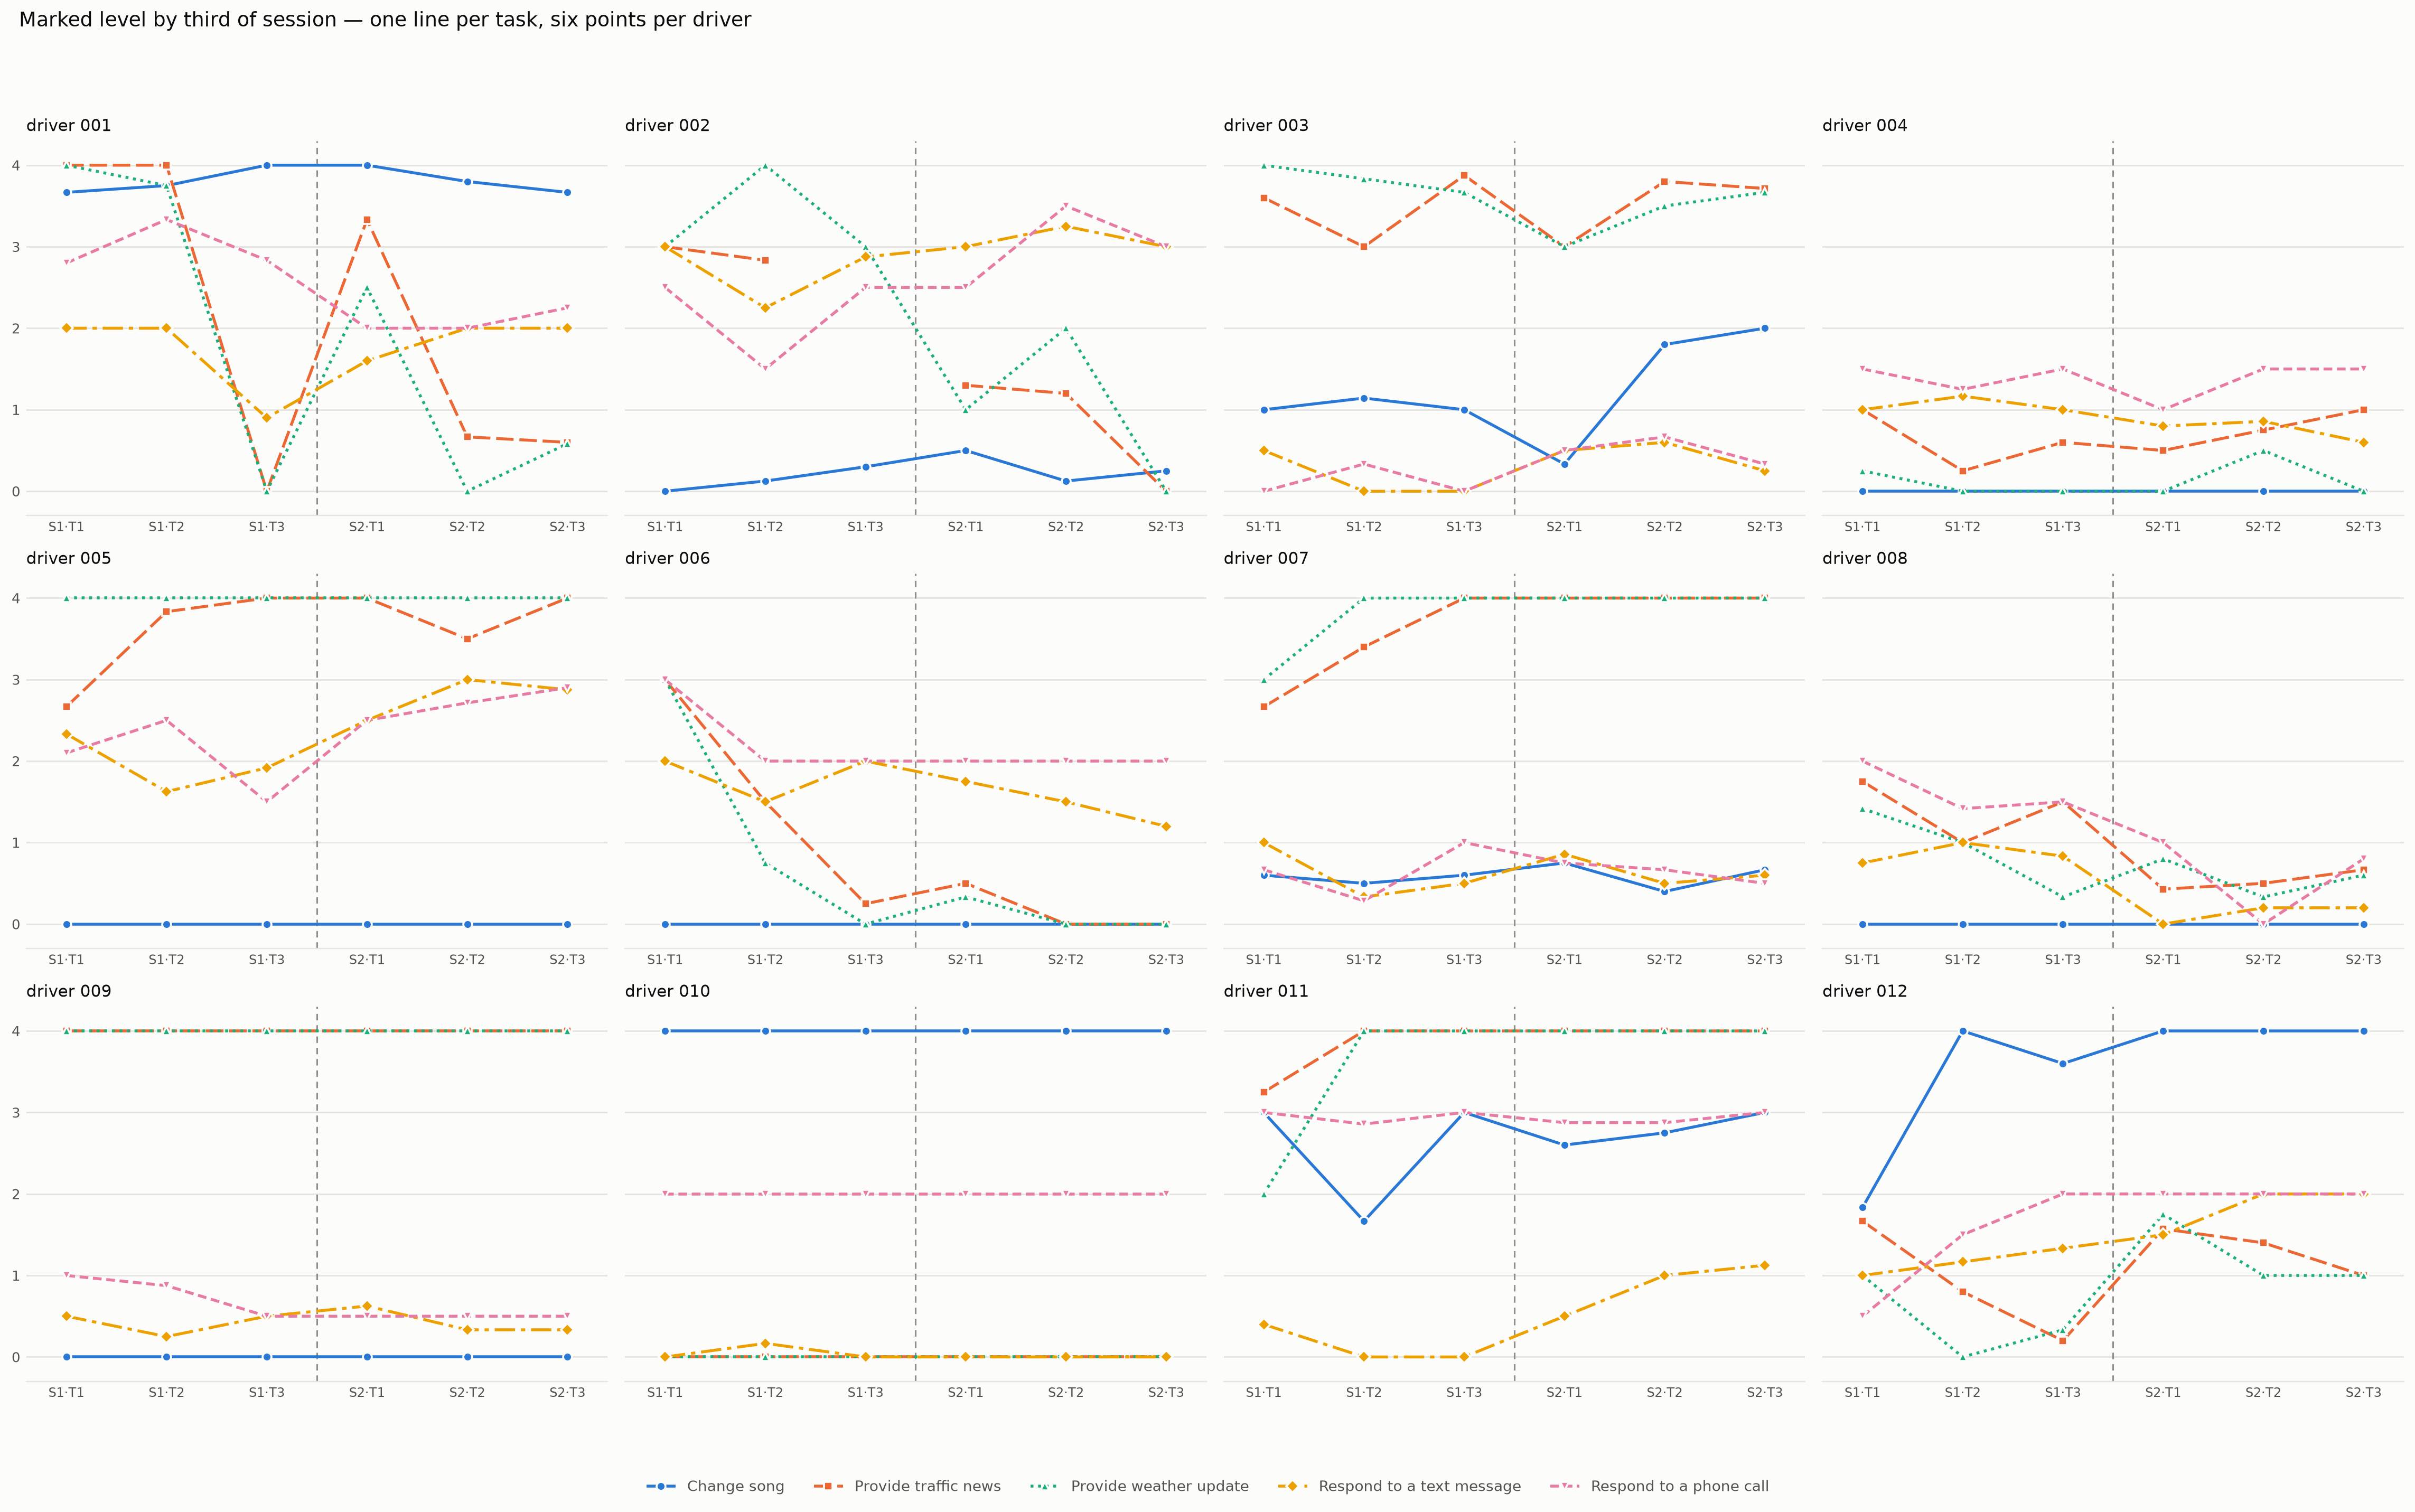

full-size, zoomable, one page per driver -> ..\results\trend_by_third_all.pdf


In [13]:
# Colour by CANONICAL task, so the mapping matches sections 1.4 onward. Fixed
# order, never cycled -- past the validated slots there is no approved hue.
if len(FUNCTIONS) > len(SERIES):
    raise ValueError(f"{len(FUNCTIONS)} tasks but {len(SERIES)} validated palette slots")
task_colours = {f: SERIES[i] for i, f in enumerate(FUNCTIONS)}
SLOTS = [(so, k) for so in sorted(seg_df.session_order.unique()) for k in range(3)]
SLOT_LAB = [f"S{so}·T{k+1}" for so, k in SLOTS]


def trend_points(sub_driver):
    """{task: [mean per (session, third)]}, np.nan where nothing was asked."""
    out = {}
    for f in FUNCTIONS:
        ys = []
        for so, k in SLOTS:
            s = sub_driver[(sub_driver.function == f) & (sub_driver.session_order == so)]
            if not len(s):
                ys.append(np.nan); continue
            nw = _maxw[(s.pid.iloc[0], s.session.iloc[0])]
            sel = s[(s.window > nw * k / 3) & (s.window <= nw * (k + 1) / 3)]
            ys.append(float(sel.y.mean()) if len(sel) else np.nan)
        out[f] = ys
    return out


def draw_trend(ax, pid, pts, compact=False):
    xs = np.arange(len(SLOTS))
    for f in FUNCTIONS:
        colour, marker, dashes = task_colours[f]
        y = np.array(pts[f], dtype=float)
        # np.nan leaves a GAP rather than bridging a third with no labels
        ax.plot(xs, y, color=colour, lw=1.8, linestyle=dashes, marker=marker,
                markersize=5.5 if compact else 7, markerfacecolor=colour,
                markeredgecolor=SURFACE, markeredgewidth=1.2, zorder=3, clip_on=False,
                label=task_label(f))
    for b in range(1, len(set(so for so, _ in SLOTS))):
        ax.axvline(b * 3 - 0.5, color=INK_MUTED, lw=1, ls=(0, (4, 3)), zorder=2)
    ax.set_ylim(-0.3, 4.3)
    ax.set_yticks(range(5))
    ax.set_yticklabels(range(5) if compact else
                       [f"{k} · {LOA_ACTIONS[k]}" for k in range(5)],
                       fontsize=8.5 if compact else 9, color=INK_2)
    ax.set_xticks(xs)
    ax.set_xticklabels(SLOT_LAB, fontsize=8 if compact else 9, color=INK_2)
    ax.set_xlim(-0.4, len(SLOTS) - 0.6)
    ax.grid(axis="y", color=GRID, lw=1, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.set_facecolor(SURFACE)
    ax.set_title(f"driver {pid}", fontsize=10, color=INK, loc="left", pad=6)


# ---- overview: all drivers as small multiples, shared y ---------------------
ncol = 4
nrow = (len(DRIVERS) + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, squeeze=False, sharey=True,
                         figsize=(FIG_SCALE * 3.6 * ncol, FIG_SCALE * 2.7 * nrow + 1.2))
fig.patch.set_facecolor(SURFACE)
for i, pid in enumerate(DRIVERS):
    draw_trend(axes[i // ncol][i % ncol], pid,
               trend_points(seg_df[seg_df.pid == pid]), compact=True)
for j in range(len(DRIVERS), nrow * ncol):
    axes[j // ncol][j % ncol].axis("off")
h, l = axes[0][0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=min(len(FUNCTIONS), 5), frameon=False,
           fontsize=9, labelcolor=INK_2, bbox_to_anchor=(0.5, 0.0))
fig.suptitle("Marked level by third of session — one line per task, six points per driver",
             fontsize=12.5, color=INK, x=0.01, ha="left", y=0.995)
fig.tight_layout(rect=(0, 0.06, 1, 0.96))
save_pdf(fig, "trend_by_third_overview")
plt.show()

# ---- one full-size page per driver, vector, zoomable ------------------------
pdf_path = OUT_DIR / "trend_by_third_all.pdf"
with PdfPages(pdf_path) as pdf:
    for pid in DRIVERS:
        f2, ax2 = plt.subplots(figsize=(FIG_SCALE * 8.2, FIG_SCALE * 4.4))
        f2.patch.set_facecolor(SURFACE)
        draw_trend(ax2, pid, trend_points(seg_df[seg_df.pid == pid]))
        ax2.set_xlabel("session · third", fontsize=9, color=INK_2)
        h, l = ax2.get_legend_handles_labels()
        f2.legend(h, l, loc="lower center", ncol=min(len(FUNCTIONS), 3), frameon=False,
                  fontsize=9, labelcolor=INK_2, bbox_to_anchor=(0.5, 0.0))
        f2.tight_layout(rect=(0, 0.13, 1, 1))
        pdf.savefig(f2, facecolor=SURFACE)
        plt.close(f2)
print(f"full-size, zoomable, one page per driver -> {pdf_path}")


### 1.8. Where is the learnable signal? — variance decomposition and set-MAE

**set-MAE** is the distance from a prediction to the *nearest* level the driver marked acceptable, which is the metric the design selects models on. It reduces to plain MAE on single-mark labels.

The four predictors are nested, and the gaps between them are what matter:
- **per-task mean** is the ceiling for a population model that never sees driver identity — the xLSTM's FCD pathway.
- **per-driver × task mean** is the ceiling for personalization.

These are *in-sample* ceilings (fitted and evaluated on the same data), so they are upper bounds, not achievable scores.

---

In [ ]:
def set_mae(pred, marks):
    """Distance to the NEAREST marked level -- plain MAE when one level is marked."""
    return min(abs(pred - m) for m in marks)


def score(name, predict):
    e = [set_mae(predict(r), r["marks"]) for r in segments]
    hit = [1.0 if int(round(predict(r))) in r["marks"] else 0.0 for r in segments]
    return {"predictor": name, "set-MAE": round(float(np.mean(e)), 3),
            "hit@round %": round(100 * float(np.mean(hit)), 1)}


gm = seg_df["y"].mean()
m_fn = seg_df.groupby("function")["y"].mean().to_dict()
m_pid = seg_df.groupby("pid")["y"].mean().to_dict()
m_pf = seg_df.groupby(["pid", "function"])["y"].mean().to_dict()

baselines = pd.DataFrame([
    score("constant (global mean)", lambda r: gm),
    score("per-DRIVER mean", lambda r: m_pid[r["pid"]]),
    score("per-FUNCTION mean   <- population-model ceiling", lambda r: m_fn[r["function"]]),
    score("per-DRIVER x FUNCTION   <- personalization ceiling",
          lambda r: m_pf[(r["pid"], r["function"])]),
])
print("In-sample ceilings")
display(baselines)
pop, per = baselines.loc[2, "set-MAE"], baselines.loc[3, "set-MAE"]
print(f"personalization vs the population ceiling: set-MAE {pop:.3f} -> {per:.3f}, "
      f"an error REDUCTION of {pop-per:.3f} ({100*(pop-per)/pop:.1f}%); "
      f"hit rate {baselines.loc[2,'hit@round %']:.1f}% -> {baselines.loc[3,'hit@round %']:.1f}%")

# ---- variance decomposition -------------------------------------------------
y = seg_df["y"].to_numpy(float)
tot = y.var()


def explained(keys):
    """Fraction of variance removed by conditioning on `keys` (grouped means)."""
    within = (seg_df.groupby(keys)["y"]
              .transform(lambda v: (v - v.mean()) ** 2).sum() / len(seg_df))
    return 1 - within / tot


rows = [
    ("function alone", explained(["function"])),
    ("driver alone", explained(["pid"])),
    ("driver x function", explained(["pid", "function"])),
    ("driver x function x session", explained(["pid", "function", "session"])),
]
vd = pd.DataFrame([{"conditioning": k, "variance explained %": round(100 * v, 1)}
                   for k, v in rows])
vd.loc[len(vd)] = {"conditioning": "-> residual left for DRIVER STATE",
                   "variance explained %": round(100 * (1 - rows[2][1]), 1)}
print(f"Variance decomposition of the segment label (total variance {tot:.3f})")
display(vd)
print("The gap between 'function alone' and 'driver x function' is the INTERACTION --")
print("the part only a per-driver model can reach. A large gap is the case for")
print("personalization; it also means the population marginal is weak by construction.")


In-sample ceilings


,predictor,set-MAE,hit@round %
0,constant (global mean),1.379,15.6
1,per-DRIVER mean,1.192,21.2
2,per-FUNCTION mean <- population-model ceiling,1.314,20.0
3,per-DRIVER x FUNCTION <- personalization ceiling,0.462,68.5


personalization vs the population ceiling: set-MAE 1.314 -> 0.462, an error REDUCTION of 0.852 (64.8%); hit rate 20.0% -> 68.5%
Variance decomposition of the segment label (total variance 2.419)


,conditioning,variance explained %
0,function alone,5.9
1,driver alone,18.4
2,driver x function,78.3
3,driver x function x session,81.8
4,-> residual left for DRIVER STATE,21.7


The gap between 'function alone' and 'driver x function' is the INTERACTION --
the part only a per-driver model can reach. A large gap is the case for
personalization; it also means the population marginal is weak by construction.
